## Calculating the deviations due to a binary lens at a specific coordinate origin
#### To minimize deviations at low magnfications, try:
$\xi \rightarrow \xi + \dfrac{q}{(1+q)(s+s^{-1})}$

#### Importing libraries

In [44]:
%load_ext autoreload
%autoreload 2

import pickle
import time as t
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt

init_time = t.time()
from IRSMicroLensing import IRSCaustics as IRSC
from IRSMicroLensing import IRSFunctions as IRSF
print(f'Custom library import time: {(t.time() - init_time):.3} seconds')

import VBMicrolensing

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Custom library import time: 0.000432 seconds


#### Defining and initializing VBMicrolensing

In [45]:
VBM = VBMicrolensing.VBMicrolensing()

# Set relative accuracy
VBM.RelTol = 1e-03

# Set accuracy
VBM.Tol=1e-03

#### Importing all simulations and checking parameters

In [181]:
# Single lens
single_lens = IRSC.caustic_reader('../Unity/Simulations/Collection_0.8/single_1e11.pkl')

# Binary lens
binary_lens = IRSC.caustic_reader('../Unity/Simulations/Collection_0.8/binary_1e11.pkl')

# All triple lens
betas = [0, 45, 90, 135, 180]
pmrs = [0.1, 0.01, 0.001]
offsets = ['', '_binary_offset', '_cm']
triple_lenses = []
triple_lenses_binary_offset = []
triple_lenses_cm_offset = []

for pmr in pmrs:
    constant_pmr = []
    constant_pmr_binary_offset = []
    constant_pmr_cm_offset = []

    for beta in betas:
        file_path = f'../Unity/Simulations/Collection_0.8/triple_1e11_{beta}_{pmr*1e-3:.0e}.pkl'
        constant_pmr.append(IRSC.caustic_reader(file_path))

        file_path = f'../Unity/Simulations/Collection_0.8/triple_1e11_{beta}_{pmr*1e-3:.0e}_binary_offset.pkl'
        constant_pmr_binary_offset.append(IRSC.caustic_reader(file_path))

        file_path = f'../Unity/Simulations/Collection_0.8/triple_1e11_{beta}_{pmr*1e-3:.0e}_cm.pkl'
        constant_pmr_cm_offset.append(IRSC.caustic_reader(file_path))

    triple_lenses.append(constant_pmr)
    triple_lenses_binary_offset.append(constant_pmr_binary_offset)
    triple_lenses_cm_offset.append(constant_pmr_cm_offset)

triple_lenses = np.array(triple_lenses)
triple_lenses_binary_offset = np.array(triple_lenses_binary_offset)
triple_lenses_cm_offset = np.array(triple_lenses_cm_offset)

#### Checking parameters

In [240]:
print(f'Angular width of single lens: {single_lens.ang_width}')
print(f'Angular width of binary lens: {binary_lens.ang_width}')

ang_width = single_lens.ang_width
pixels = single_lens.pixels

# for triple_lens in triple_lenses:
#     print(triple_lens.lens_att)

print(triple_lenses[0, 0].lens_att)
print(triple_lenses_binary_offset[2, 0].lens_att)

Angular width of single lens: 0.07680319680319682
Angular width of binary lens: 0.07680319680319682
[[-4.4745011e-04  0.0000000e+00  1.0000000e+00]
 [ 7.9955255e-01  0.0000000e+00  1.0000000e-03]
 [ 7.9955255e-01  0.0000000e+00  1.0000000e-04]]
[[-4.87317560e-04  0.00000000e+00  1.00000000e+00]
 [ 7.99512682e-01  0.00000000e+00  1.00000000e-03]
 [ 7.99512682e-01  0.00000000e+00  1.00000000e-06]]


#### Plotting all simulations

Plotting magnification map: 0.131 seconds
Plotting magnification map: 0.031 seconds


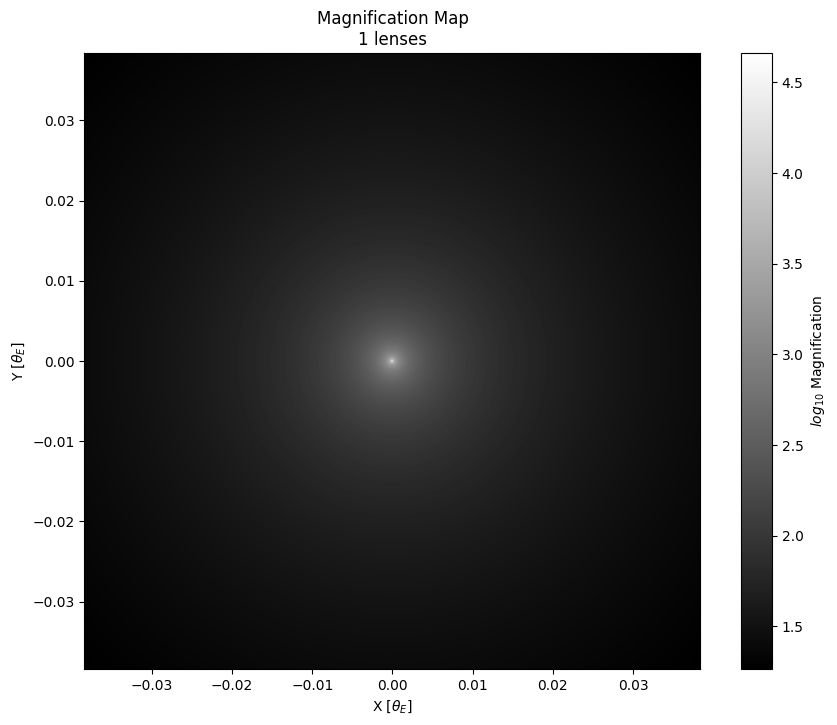

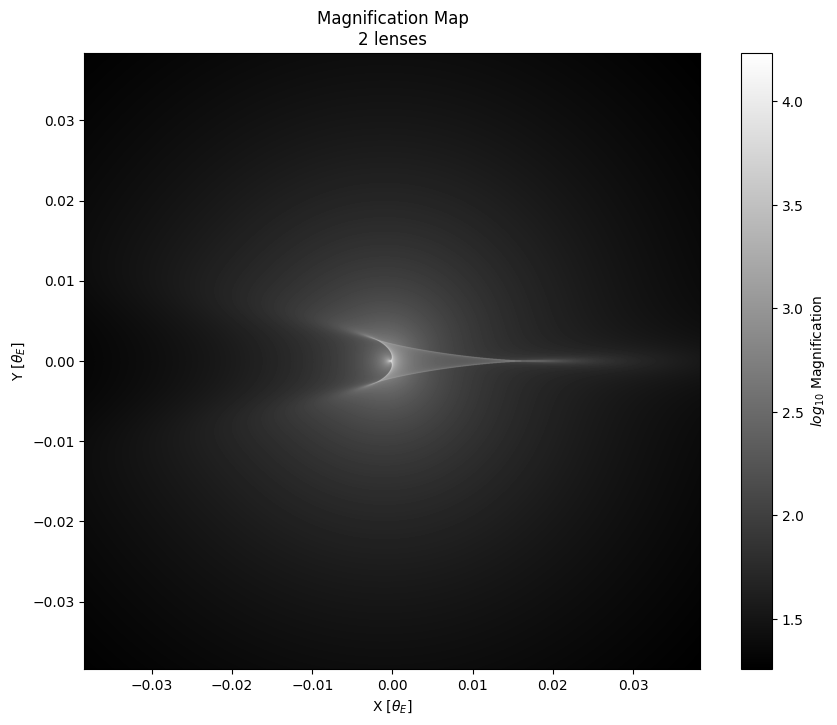

In [183]:
# Single lens
single_lens.plot()

# Binary lens
binary_lens.plot()

#### Calculating VBMicrolensing caustic

In [184]:
all_caustic_points = []
all_caustic_points_binary_offset = []
all_caustic_points_cm_offset = []

for row in triple_lenses:
    constant_pmr = []
    for triple_lens in row:
        parameters = [item for sublist in triple_lens.lens_att for idx, item in enumerate(sublist)]
        VBM.SetLensGeometry(parameters)

        caustic_points = VBM.Multicaustics()
        constant_pmr.append(caustic_points)
    
    all_caustic_points.append(constant_pmr)

for row in triple_lenses_binary_offset:
    constant_pmr = []
    for triple_lens in row:
        parameters = [item for sublist in triple_lens.lens_att for idx, item in enumerate(sublist)]
        VBM.SetLensGeometry(parameters)

        caustic_points = VBM.Multicaustics()
        constant_pmr.append(caustic_points)
    
    all_caustic_points_binary_offset.append(constant_pmr)

for row in triple_lenses_cm_offset:
    constant_pmr = []
    for triple_lens in row:
        parameters = [item for sublist in triple_lens.lens_att for idx, item in enumerate(sublist)]
        VBM.SetLensGeometry(parameters)

        caustic_points = VBM.Multicaustics()
        constant_pmr.append(caustic_points)
    
    all_caustic_points_cm_offset.append(constant_pmr)
# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot()

# all_cusp_xs = []
# all_cusp_ys = []
# all_min_indices = []
# all_min_distances = []

# for points in caustic_points:
#     ax.plot(points[0], points[1])
#     xs, ys = IRSF.IRSFunctions.find_cusp_points(np.array(points))
    
#     xs = np.array(xs)
#     ys = np.array(ys)

#     all_cusp_xs.append(xs)
#     all_cusp_ys.append(ys)

#     cusp_distances = np.sqrt(xs**2 + ys**2)
#     min_indices = np.argmin(cusp_distances)

#     all_min_distances.append(cusp_distances[min_indices])
#     all_min_indices.append(min_indices)

# min_ind = np.argmin(np.array(all_min_distances))

# print(all_cusp_xs[min_ind][all_min_indices[min_ind]], all_cusp_ys[min_ind][all_min_indices[min_ind]])

# big_caustic_xs = np.array(caustic_points[min_ind][0])
# big_caustic_ys = np.array(caustic_points[min_ind][1])

# ax.set_xlim(-ang_width/4, ang_width/4)
# ax.set_ylim(-ang_width/4, ang_width/4)
# ax.set_aspect('equal')

# plt.show()

#### Defining source parameters

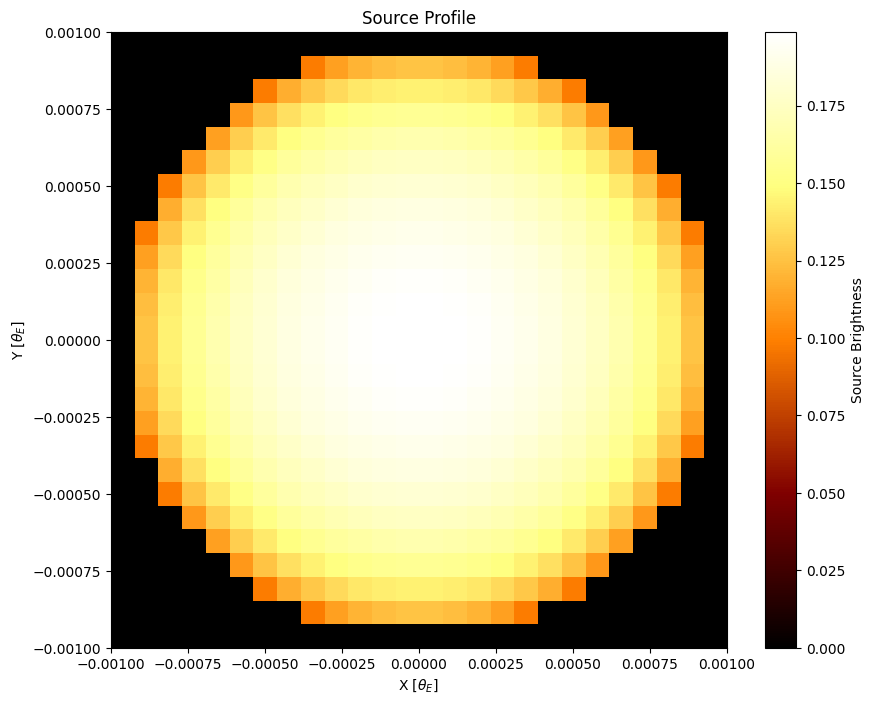

In [185]:
radius = 1e-3
LD = 0.5

source_profile = IRSF.IRSFunctions.source_profile(ang_res=single_lens.param_dict['ang_res'], rad=radius, profile_type='LD', LD=LD)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

img = ax.imshow(source_profile, cmap='afmhot', extent=[-radius, radius, -radius, radius])
plt.colorbar(img, ax=ax, label='Source Brightness')

ax.set_xlabel('X [$\\theta_E$]')
ax.set_ylabel('Y [$\\theta_E$]')
ax.set_title('Source Profile')

ax.set_aspect('equal')

plt.show()

#### Convolving all lens configurations

In [186]:
# Single lens
convolved_single_lens = single_lens.convolve(source_profile=source_profile)

# Binary lens
convolved_binary_lens = binary_lens.convolve(source_profile=source_profile)

# All triple lenses
convolved_triple_lenses = []
convolved_triple_lenses_cm_offset = []
convolved_triple_lenses_binary_offset = []

for row in triple_lenses:
    constant_pmr = []
    for triple_lens in row:
        convolved_triple_lens = triple_lens.convolve(source_profile=source_profile)
        constant_pmr.append(convolved_triple_lens)
    
    convolved_triple_lenses.append(constant_pmr)

for row in triple_lenses_binary_offset:
    constant_pmr = []
    for triple_lens in row:
        convolved_triple_lens = triple_lens.convolve(source_profile=source_profile)
        constant_pmr.append(convolved_triple_lens)
    
    convolved_triple_lenses_binary_offset.append(constant_pmr)

for row in triple_lenses_cm_offset:
    constant_pmr = []
    for triple_lens in row:
        convolved_triple_lens = triple_lens.convolve(source_profile=source_profile)
        constant_pmr.append(convolved_triple_lens)
    
    convolved_triple_lenses_cm_offset.append(constant_pmr)

convolved_triple_lenses = np.array(convolved_triple_lenses)
convolved_triple_lenses_binary_offset = np.array(convolved_triple_lenses_binary_offset)
convolved_triple_lenses_cm_offset = np.array(convolved_triple_lenses_cm_offset)

Convolving source profile with magnification map: 0.152 seconds
Convolving source profile with magnification map: 0.093 seconds
Convolving source profile with magnification map: 0.092 seconds
Convolving source profile with magnification map: 0.095 seconds
Convolving source profile with magnification map: 0.093 seconds
Convolving source profile with magnification map: 0.095 seconds
Convolving source profile with magnification map: 0.092 seconds
Convolving source profile with magnification map: 0.093 seconds
Convolving source profile with magnification map: 0.095 seconds
Convolving source profile with magnification map: 0.094 seconds
Convolving source profile with magnification map: 0.095 seconds
Convolving source profile with magnification map: 0.094 seconds
Convolving source profile with magnification map: 0.093 seconds
Convolving source profile with magnification map: 0.095 seconds
Convolving source profile with magnification map: 0.095 seconds
Convolving source profile with magnifica

#### Calculating fractional deviations from single and binary for all triple lens configurations

In [187]:
# Single lens deviations
fractional_deviation_single = []
fractional_deviation_single_binary_offset = []
fractional_deviation_single_cm_offset = []

# Binary lens deviations
fractional_deviation_binary = []
fractional_deviation_binary_binary_offset = []
fractional_deviation_binary_cm_offset = []

for row in convolved_triple_lenses:
    constant_pmr_single = []
    constant_pmr_binary = []

    for convolved_triple_lens in row:
        constant_pmr_single.append( (convolved_triple_lens - convolved_single_lens)/convolved_single_lens )
        constant_pmr_binary.append( (convolved_triple_lens - convolved_binary_lens)/convolved_binary_lens )

    fractional_deviation_single.append(constant_pmr_single)
    fractional_deviation_binary.append(constant_pmr_binary)

for row in convolved_triple_lenses_binary_offset:
    constant_pmr_single = []
    constant_pmr_binary = []

    for convolved_triple_lens in row:
        constant_pmr_single.append( (convolved_triple_lens - convolved_single_lens)/convolved_single_lens )
        constant_pmr_binary.append( (convolved_triple_lens - convolved_binary_lens)/convolved_binary_lens )

    fractional_deviation_single_binary_offset.append(constant_pmr_single)
    fractional_deviation_binary_binary_offset.append(constant_pmr_binary)

for row in convolved_triple_lenses_cm_offset:
    constant_pmr_single = []
    constant_pmr_binary = []

    for convolved_triple_lens in row:
        constant_pmr_single.append( (convolved_triple_lens - convolved_single_lens)/convolved_single_lens )
        constant_pmr_binary.append( (convolved_triple_lens - convolved_binary_lens)/convolved_binary_lens )

    fractional_deviation_single_cm_offset.append(constant_pmr_single)
    fractional_deviation_binary_cm_offset.append(constant_pmr_binary)

fractional_deviation_single = np.array(fractional_deviation_single)
fractional_deviation_single_binary_offset = np.array(fractional_deviation_single_binary_offset)
fractional_deviation_single_cm_offset = np.array(fractional_deviation_single_cm_offset)

fractional_deviation_binary = np.array(fractional_deviation_binary)
fractional_deviation_binary_binary_offset = np.array(fractional_deviation_binary_binary_offset)
fractional_deviation_binary_cm_offset = np.array(fractional_deviation_binary_cm_offset)

In [188]:
print(fractional_deviation_single.shape)
print(fractional_deviation_single_binary_offset.shape)
print(fractional_deviation_single_cm_offset.shape)

print(fractional_deviation_binary.shape)
print(fractional_deviation_binary_binary_offset.shape)
print(fractional_deviation_binary_cm_offset.shape)

(3, 5, 2000, 2000)
(3, 5, 2000, 2000)
(3, 5, 2000, 2000)
(3, 5, 2000, 2000)
(3, 5, 2000, 2000)
(3, 5, 2000, 2000)


#### Plotting all fractional deviations

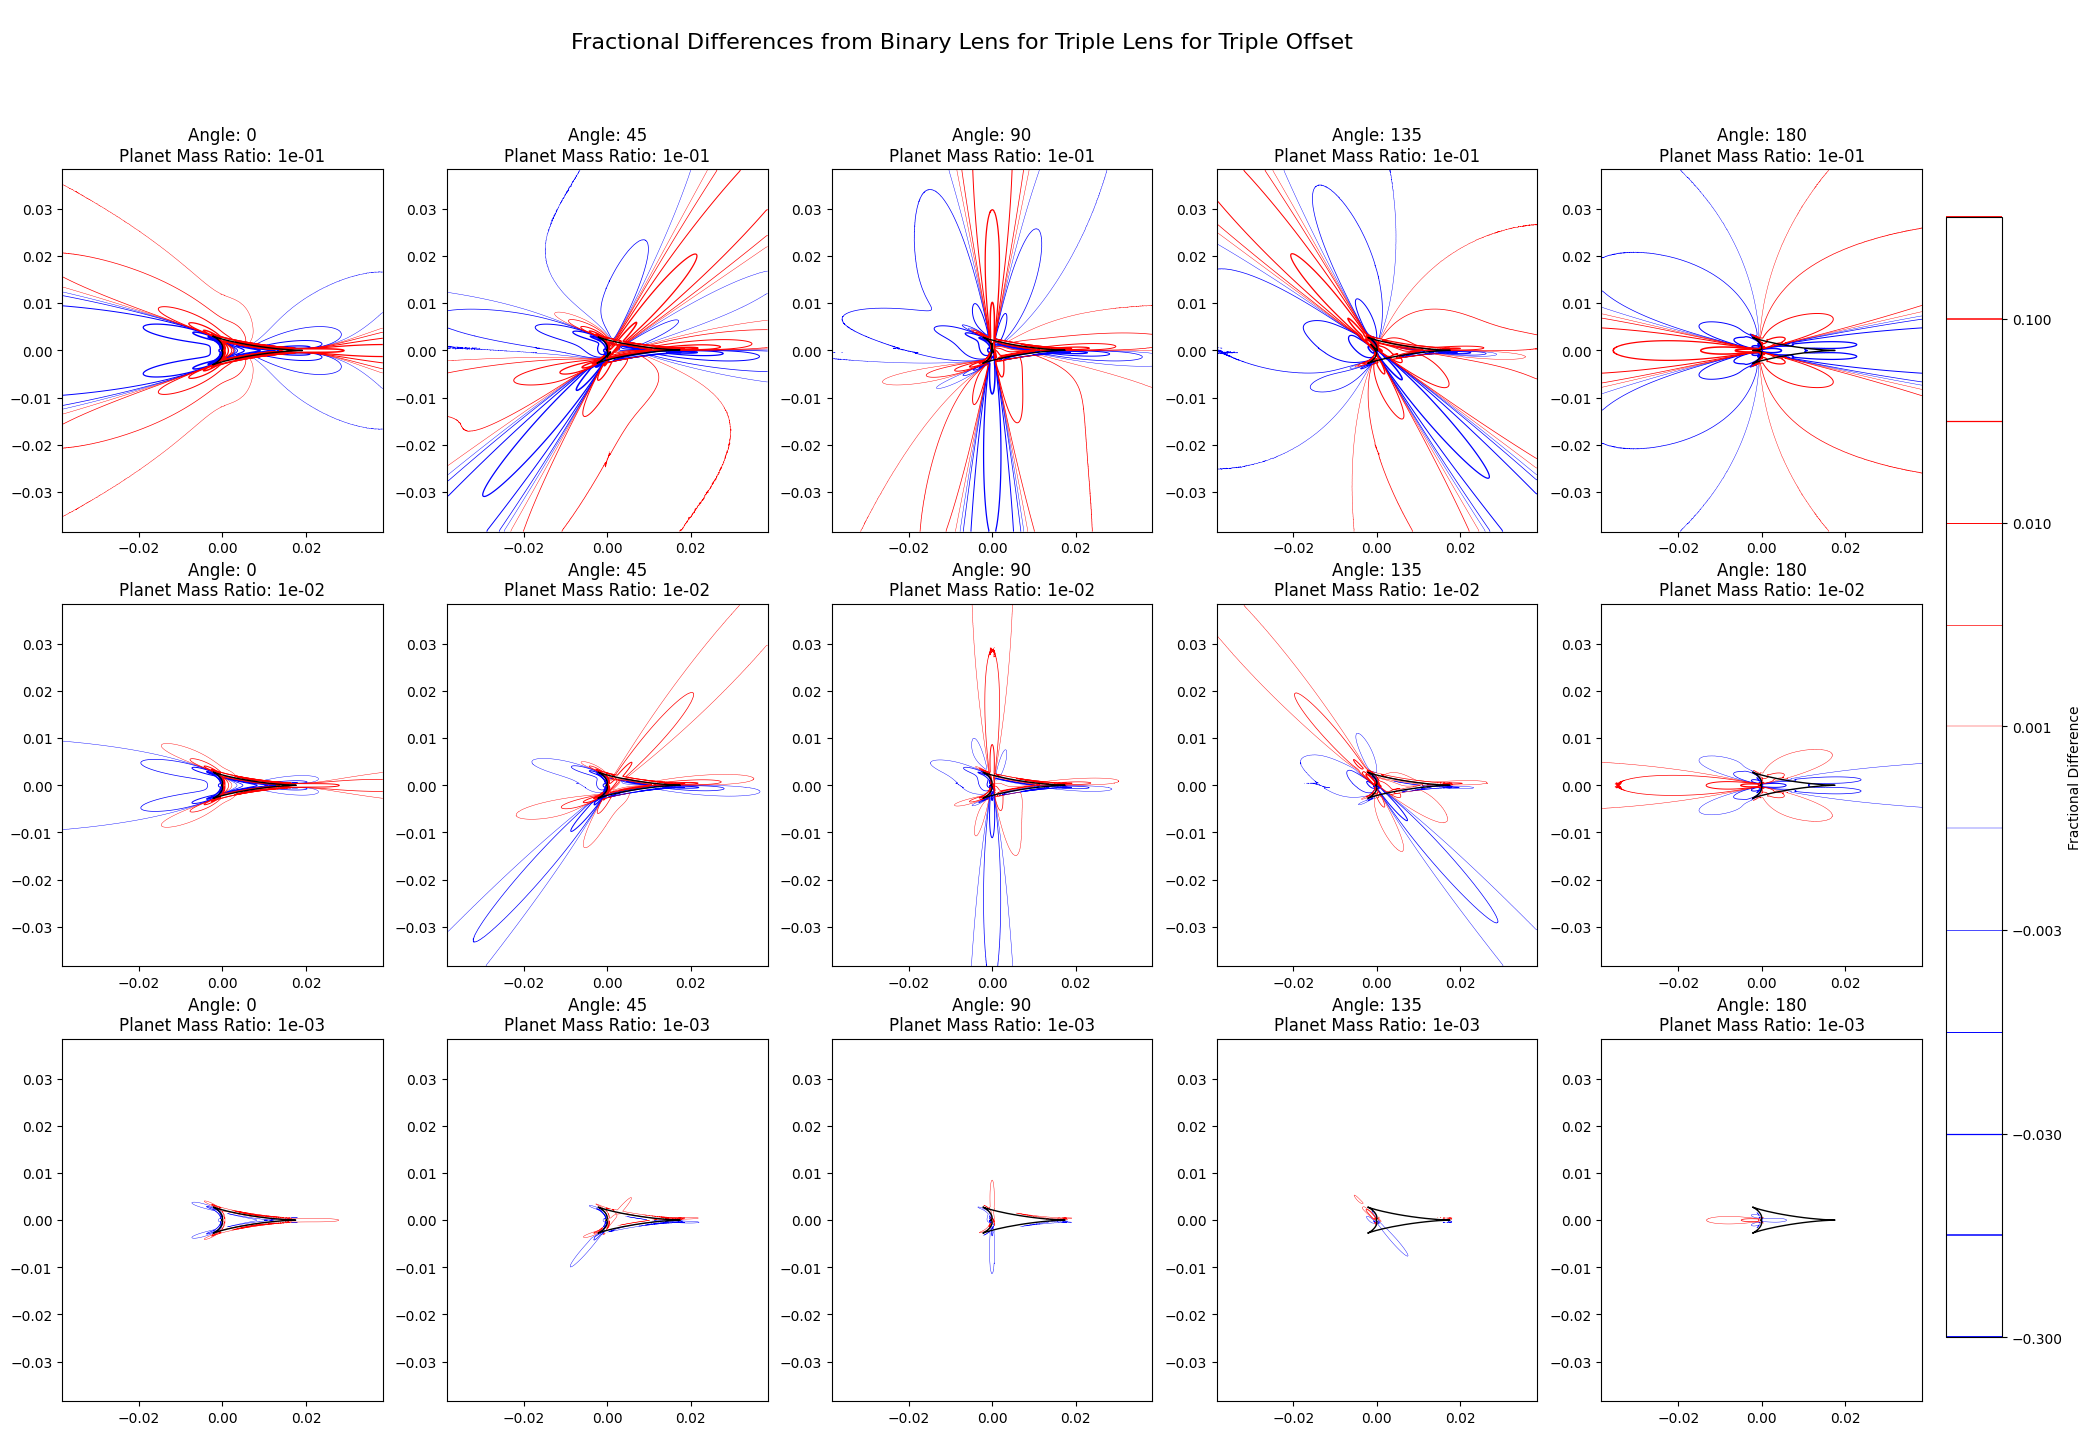

In [189]:
fig = plt.figure(figsize=(24, 16))
all_axes = fig.subplots(3, 5)
axes = all_axes

fig.suptitle('\nFractional Differences from Binary Lens for Triple Lens for Triple Offset', fontsize=16)

for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {betas[j]}\nPlanet Mass Ratio: {(pmrs[i]):.0e}')

        caustic_points = all_caustic_points[i][j]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10)

        img = ax.contour(single_lens.X_pix, single_lens.Y_pix, np.flip(fractional_deviation_binary[i, j], axis=0),
                levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                zorder=0
        )

        ax.set_xlim(-ang_width/2, ang_width/2)
        ax.set_ylim(-ang_width/2, ang_width/2)
        
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar_ax.axis('off')

bar = fig.colorbar(img, ax=cbar_ax, location='right', fraction=1.5, aspect=20)
bar.set_label('Fractional Difference')

# fig.savefig('Fractional Difference Contours CM Offset.png', dpi=500)

plt.show()

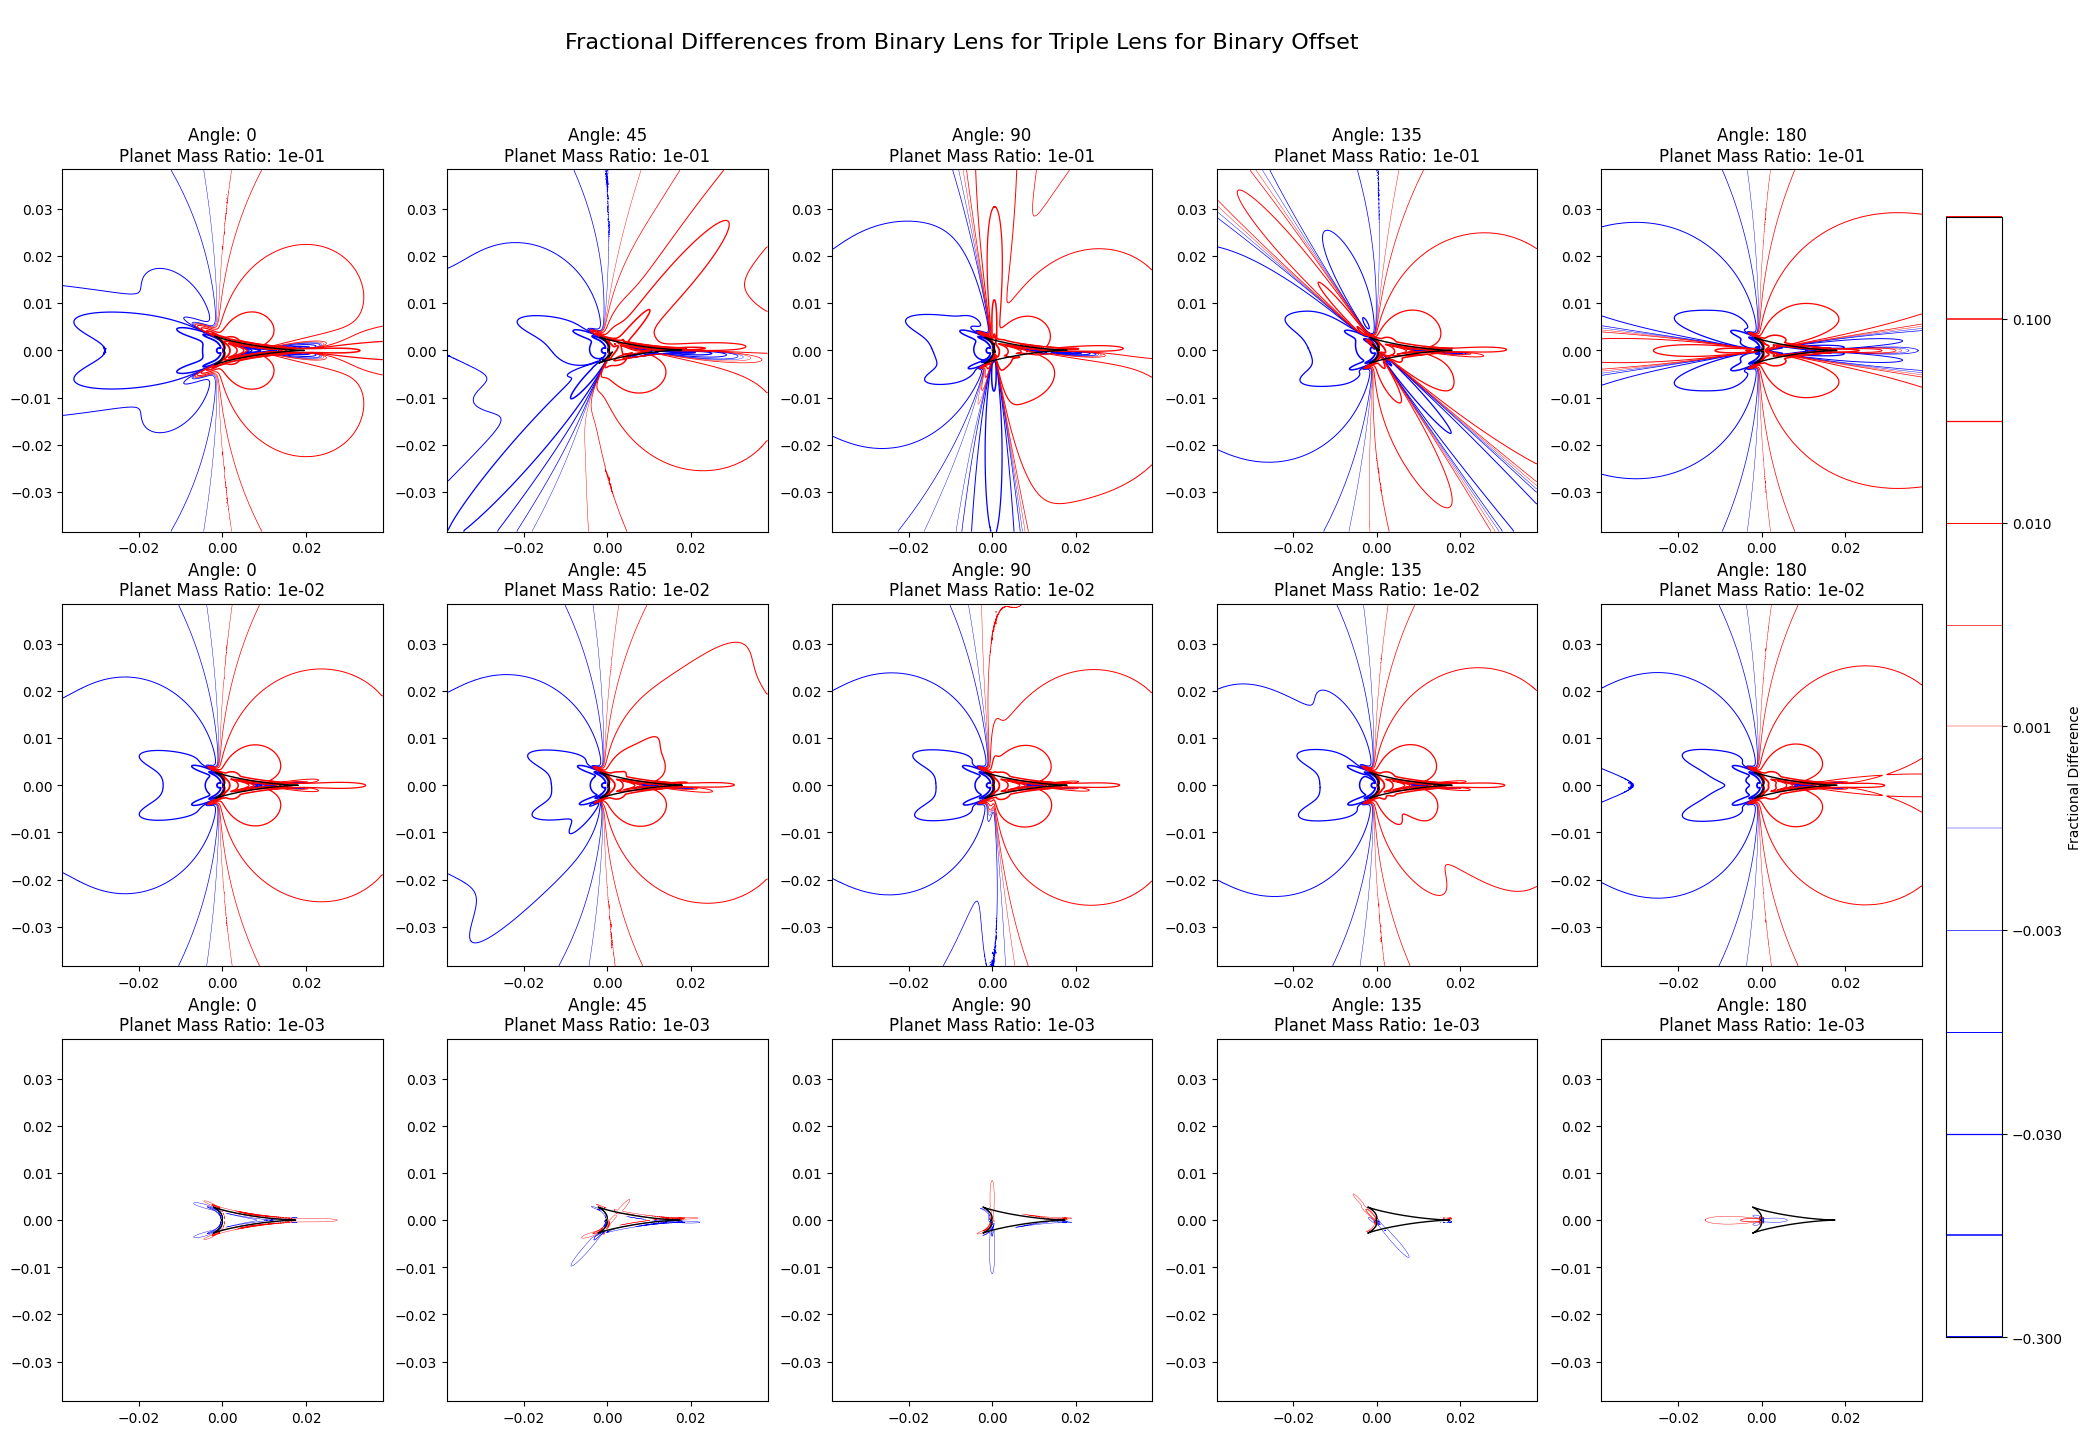

In [190]:
fig = plt.figure(figsize=(24, 16))
all_axes = fig.subplots(3, 5)
axes = all_axes

fig.suptitle('\nFractional Differences from Binary Lens for Triple Lens for Binary Offset', fontsize=16)

for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {betas[j]}\nPlanet Mass Ratio: {(pmrs[i]):.0e}')

        caustic_points = all_caustic_points_binary_offset[i][j]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10)

        img = ax.contour(single_lens.X_pix, single_lens.Y_pix, np.flip(fractional_deviation_binary_binary_offset[i, j], axis=0),
                levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                zorder=0
        )

        ax.set_xlim(-ang_width/2, ang_width/2)
        ax.set_ylim(-ang_width/2, ang_width/2)
        
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar_ax.axis('off')

bar = fig.colorbar(img, ax=cbar_ax, location='right', fraction=1.5, aspect=20)
bar.set_label('Fractional Difference')

# fig.savefig('Fractional Difference Contours CM Offset.png', dpi=500)

plt.show()

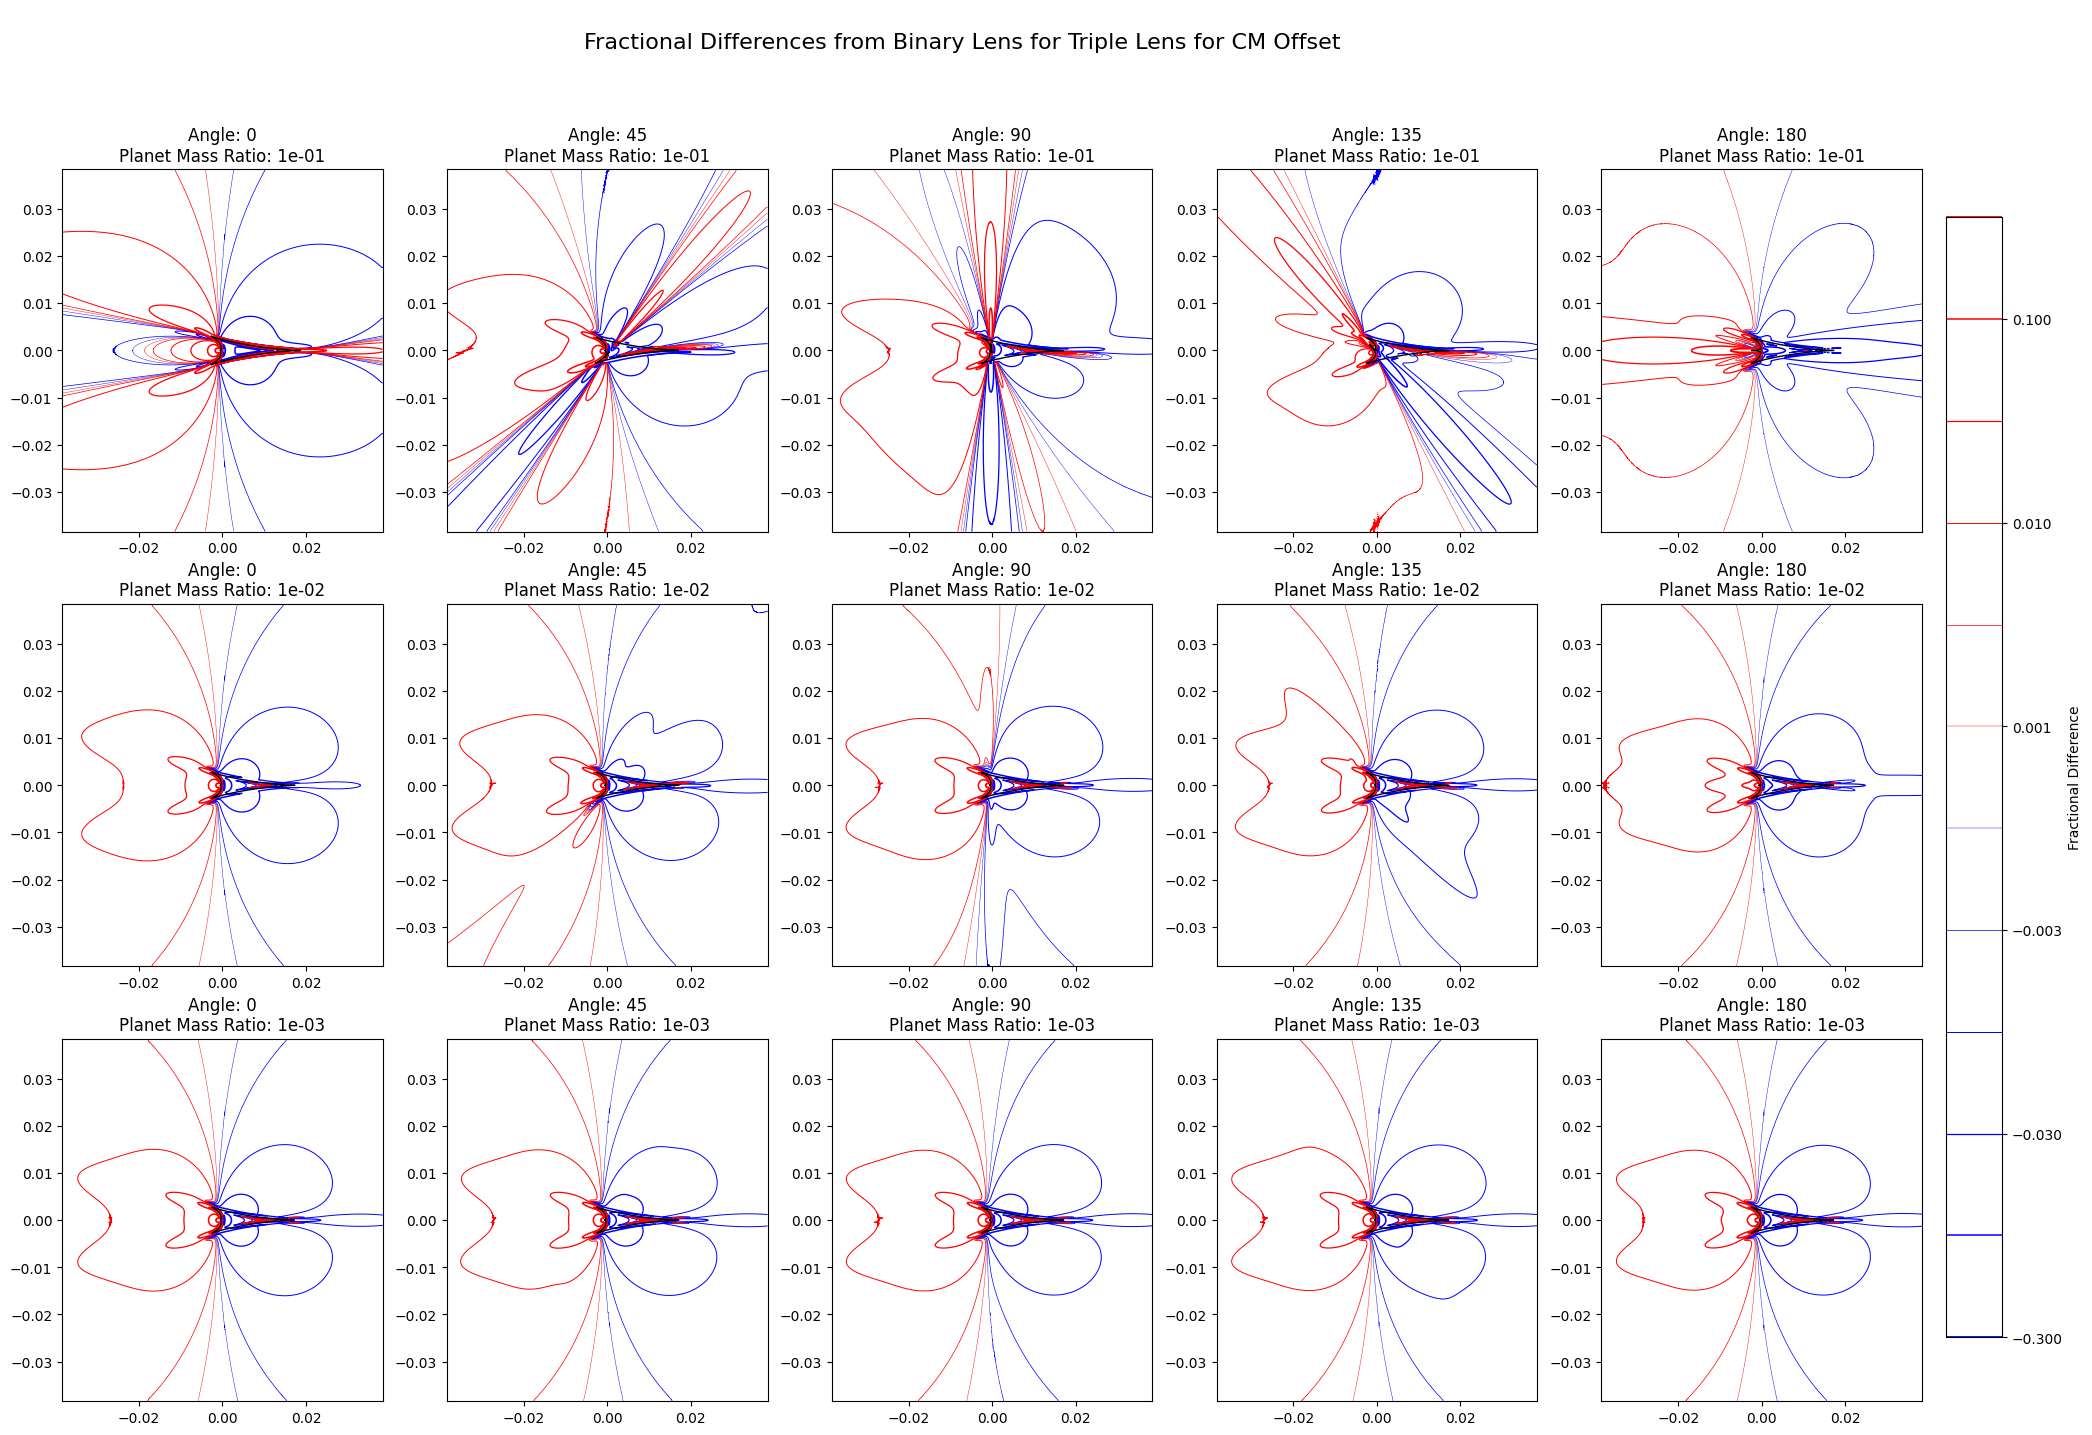

In [191]:
fig = plt.figure(figsize=(24, 16))
all_axes = fig.subplots(3, 5)
axes = all_axes

fig.suptitle('\nFractional Differences from Binary Lens for Triple Lens for CM Offset', fontsize=16)

for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {betas[j]}\nPlanet Mass Ratio: {(pmrs[i]):.0e}')

        caustic_points = all_caustic_points_cm_offset[i][j]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10)

        img = ax.contour(single_lens.X_pix, single_lens.Y_pix, np.flip(fractional_deviation_binary_cm_offset[i, j], axis=0),
                levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                zorder=0
        )

        ax.set_xlim(-ang_width/2, ang_width/2)
        ax.set_ylim(-ang_width/2, ang_width/2)
        
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar_ax.axis('off')

bar = fig.colorbar(img, ax=cbar_ax, location='right', fraction=1.5, aspect=20)
bar.set_label('Fractional Difference')

# fig.savefig('Fractional Difference Contours CM Offset.png', dpi=500)

plt.show()

#### Calculating cumulative distributions to determine the best offset

In [126]:
xs = np.logspace(-5, 0, 100)
print(xs)

cumulative_area_distribution = []
cumulative_area_distribution_binary_offset = []
cumulative_area_distribution_cm_offset = []

for x in xs:
    cumulative_area_distribution.append(np.sum(np.abs(fractional_deviation_binary) < x, axis=(2, 3)) / (pixels**2))
    cumulative_area_distribution_binary_offset.append(np.sum(np.abs(fractional_deviation_binary_binary_offset) < x, axis=(2, 3)) / (pixels**2))
    cumulative_area_distribution_cm_offset.append(np.sum(np.abs(fractional_deviation_binary_cm_offset) < x, axis=(2, 3)) / (pixels**2))

cumulative_area_distribution = np.array(cumulative_area_distribution)
cumulative_area_distribution_binary_offset = np.array(cumulative_area_distribution_binary_offset)
cumulative_area_distribution_cm_offset = np.array(cumulative_area_distribution_cm_offset)

[1.00000000e-05 1.12332403e-05 1.26185688e-05 1.41747416e-05
 1.59228279e-05 1.78864953e-05 2.00923300e-05 2.25701972e-05
 2.53536449e-05 2.84803587e-05 3.19926714e-05 3.59381366e-05
 4.03701726e-05 4.53487851e-05 5.09413801e-05 5.72236766e-05
 6.42807312e-05 7.22080902e-05 8.11130831e-05 9.11162756e-05
 1.02353102e-04 1.14975700e-04 1.29154967e-04 1.45082878e-04
 1.62975083e-04 1.83073828e-04 2.05651231e-04 2.31012970e-04
 2.59502421e-04 2.91505306e-04 3.27454916e-04 3.67837977e-04
 4.13201240e-04 4.64158883e-04 5.21400829e-04 5.85702082e-04
 6.57933225e-04 7.39072203e-04 8.30217568e-04 9.32603347e-04
 1.04761575e-03 1.17681195e-03 1.32194115e-03 1.48496826e-03
 1.66810054e-03 1.87381742e-03 2.10490414e-03 2.36448941e-03
 2.65608778e-03 2.98364724e-03 3.35160265e-03 3.76493581e-03
 4.22924287e-03 4.75081016e-03 5.33669923e-03 5.99484250e-03
 6.73415066e-03 7.56463328e-03 8.49753436e-03 9.54548457e-03
 1.07226722e-02 1.20450354e-02 1.35304777e-02 1.51991108e-02
 1.70735265e-02 1.917910

#### Plotting cumulative area distributions

In [127]:
print(cumulative_area_distribution.shape)

(100, 3, 5)


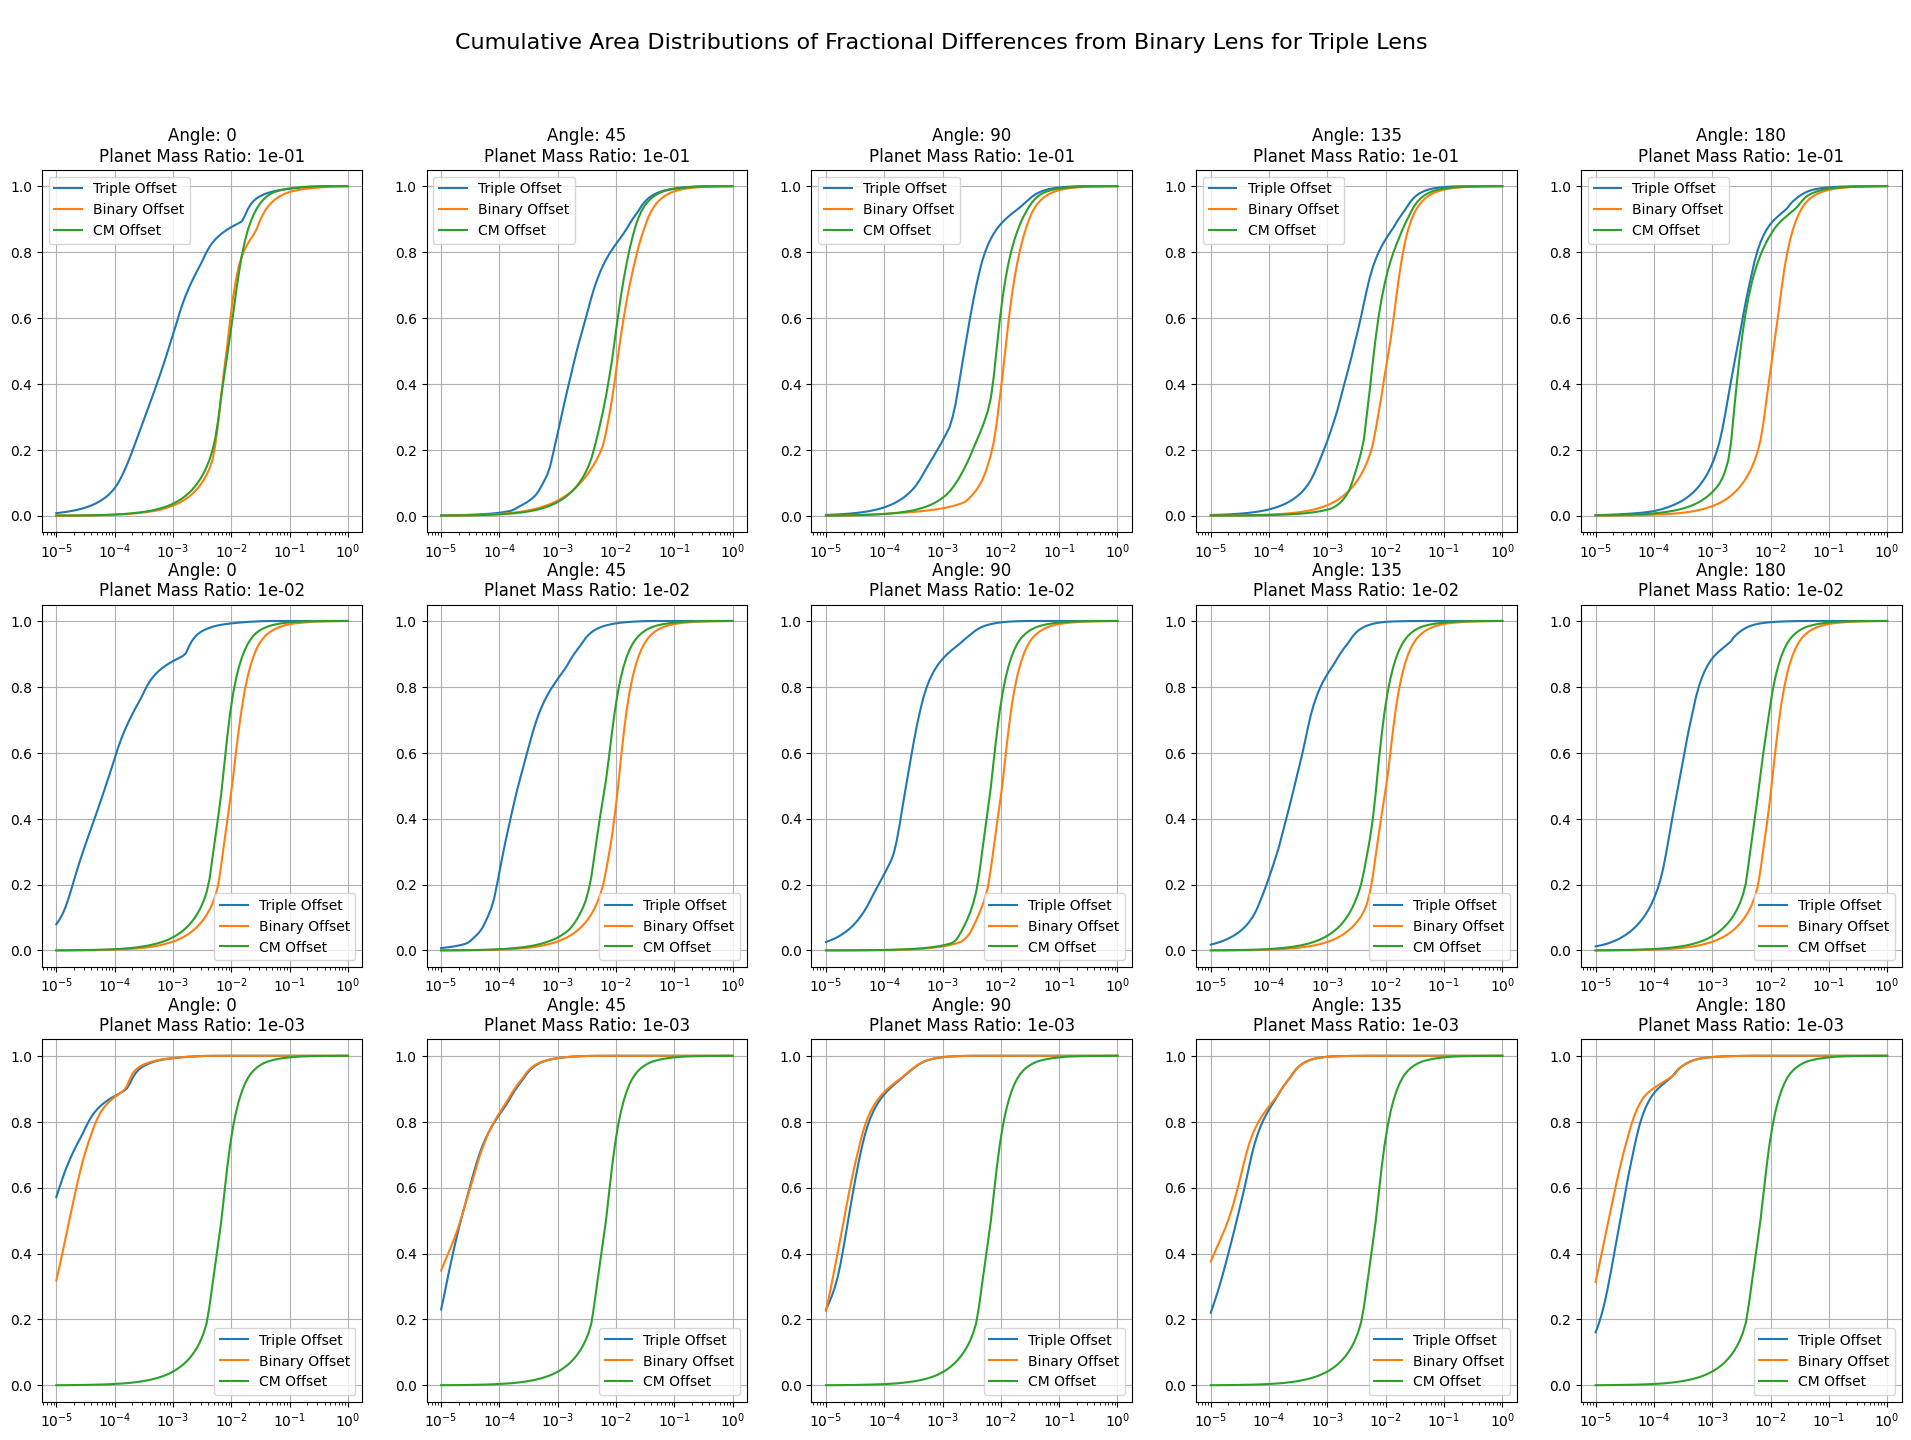

In [ ]:
fig = plt.figure(figsize=(24, 16))
all_axes = fig.subplots(3, 5)
axes = all_axes

fig.suptitle('\nCumulative Area Distributions of Fractional Differences from Binary Lens for Triple Lens', fontsize=16)

for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {betas[j]}\nPlanet Mass Ratio: {(pmrs[i]):.0e}')

        ax.plot(xs, cumulative_area_distribution[:, i, j], label='Triple Offset')
        ax.plot(xs, cumulative_area_distribution_binary_offset[:, i, j], label='Binary Offset')
        ax.plot(xs, cumulative_area_distribution_cm_offset[:, i, j], label='CM Offset')

        ax.set_xscale('log')
        ax.grid(True)
        ax.legend()

fig.savefig('Cumulative Area Distribution Triple Lens.png', dpi=500)

plt.show()

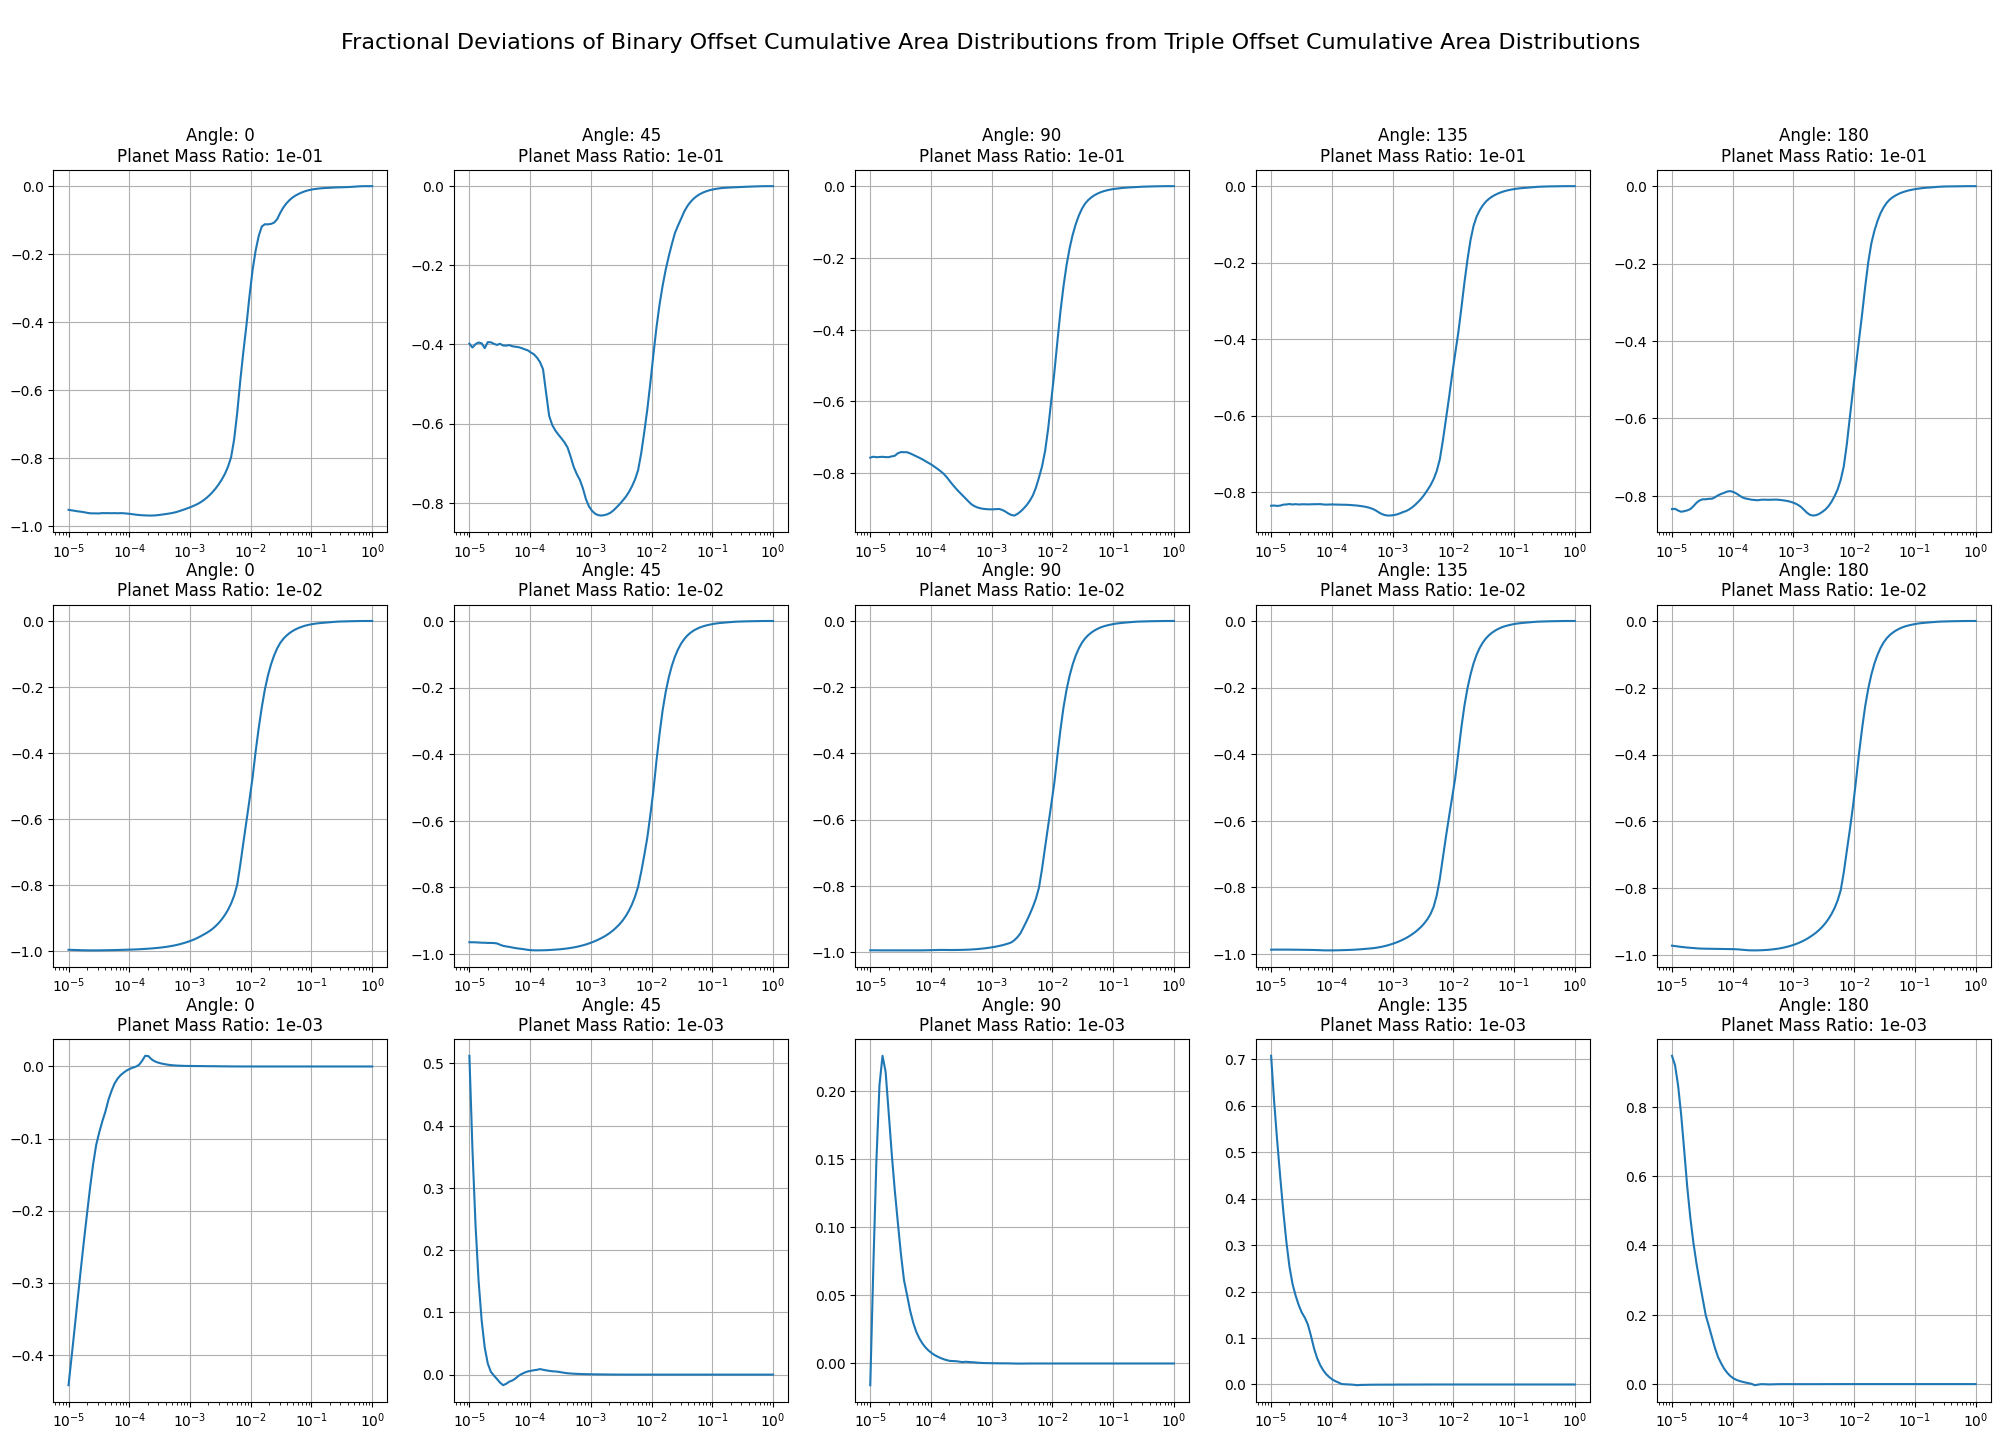

In [ ]:
fig = plt.figure(figsize=(25, 16))
all_axes = fig.subplots(3, 5)
axes = all_axes

fig.suptitle('\nFractional Deviations of Binary Offset Cumulative Area Distributions from Triple Offset Cumulative Area Distributions', fontsize=16)

for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {betas[j]}\nPlanet Mass Ratio: {(pmrs[i]):.0e}')

        ax.plot(xs, (cumulative_area_distribution_binary_offset[:, i, j] - cumulative_area_distribution[:, i, j]) / cumulative_area_distribution[:, i, j])
        # ax.plot(xs, (cumulative_area_distribution_cm_offset[:, i, j] - cumulative_area_distribution[:, i, j]) / cumulative_area_distribution[:, i, j], label='FD of CM from Triple Offset')

        ax.set_xscale('log')
        ax.grid(True)
        # ax.legend()

# fig.savefig('Cumulative Area Distribution Fractional Deviation.png', dpi=500)

plt.show()

#### Geneating light curves

In [218]:
# Distribution of impact parameters and angle with respect to binary axis
us = np.linspace(-ang_width/2, ang_width/2, 6)
alphas = np.linspace(-90, 90, 5)

print(us)
print(alphas)

time_distribution = []
x_distribution = []
y_distribution = []

brightness_distribution = []
brightness_distribution_binary_offset = []
brightness_distribution_cm_offset = []

for i, row in enumerate(triple_lenses):
    constant_pmr = []
    constant_pmr_times = []
    constant_pmr_x = []
    constant_pmr_y = []

    for j, triple_lens in enumerate(row):
        one_configuration = []
        one_configuration_times = []
        one_configuration_x = []
        one_configuration_y = []

        for u in us:
            constant_u = []
            constant_u_times = []
            constant_u_x = []
            constant_u_y = []

            for alpha in alphas:
                intersections, (xs, ys), times, brightness = IRSC.IRSCaustics.lightcurve_calculator(u, alpha, ang_width, convolved_triple_lenses[i, j])
                constant_u.append(brightness)
                constant_u_times.append(times)
                constant_u_x.append(xs)
                constant_u_y.append(ys)

            one_configuration.append(constant_u)
            one_configuration_times.append(constant_u_times)
            one_configuration_x.append(constant_u_x)
            one_configuration_y.append(constant_u_y)
        
        constant_pmr.append(one_configuration)
        constant_pmr_times.append(one_configuration_times)
        constant_pmr_x.append(one_configuration_x)
        constant_pmr_y.append(one_configuration_y)

    brightness_distribution.append(constant_pmr)
    time_distribution.append(constant_pmr_times)
    x_distribution.append(constant_pmr_x)
    y_distribution.append(constant_pmr_y)


[-0.0384016  -0.02304096 -0.00768032  0.00768032  0.02304096  0.0384016 ]
[-90. -45.   0.  45.  90.]


/Users/saividyud/Documents/GitHub/NBLens/Unity Analysis/../IRSMicroLensing/IRSCaustics.py:1370: RuntimeWarning: invalid value encountered in scalar divide
  t = (y_edge - y0) / dy
/Users/saividyud/Documents/GitHub/NBLens/Unity Analysis/../IRSMicroLensing/IRSCaustics.py:1370: RuntimeWarning: divide by zero encountered in scalar divide
  t = (y_edge - y0) / dy


In [219]:
time_distribution = np.array(time_distribution, dtype=np.ndarray)
brightness_distribution = np.array(brightness_distribution, dtype=np.ndarray)
x_distribution = np.array(x_distribution, dtype=np.ndarray)
y_distribution = np.array(y_distribution, dtype=np.ndarray)

print(time_distribution.shape)
print(brightness_distribution.shape)
print(x_distribution.shape)
print(y_distribution.shape)

(3, 5, 6, 5)
(3, 5, 6, 5)
(3, 5, 6, 5)
(3, 5, 6, 5)


#### VBMicrolensing binary light curves

In [ ]:
# Initializing parameters
s = 0.8
q = 1e-3
rho = radius
tE = 1.0
t0 = 0

# Calculating light curve for binary lens


for u in us:
    for alpha in alphas:
        parameters = [
            np.log(0.8),
            np.log(1e-3),
        ]

#### Choosing what light curve to plot

In [231]:
one_curve = True

ind_u = 3
ind_alpha = 2

print(f'u = {us[ind_u]:.5f}')
print(f'alpha = {alphas[ind_alpha]:.3f} degrees')

u = 0.00768
alpha = 0.000 degrees


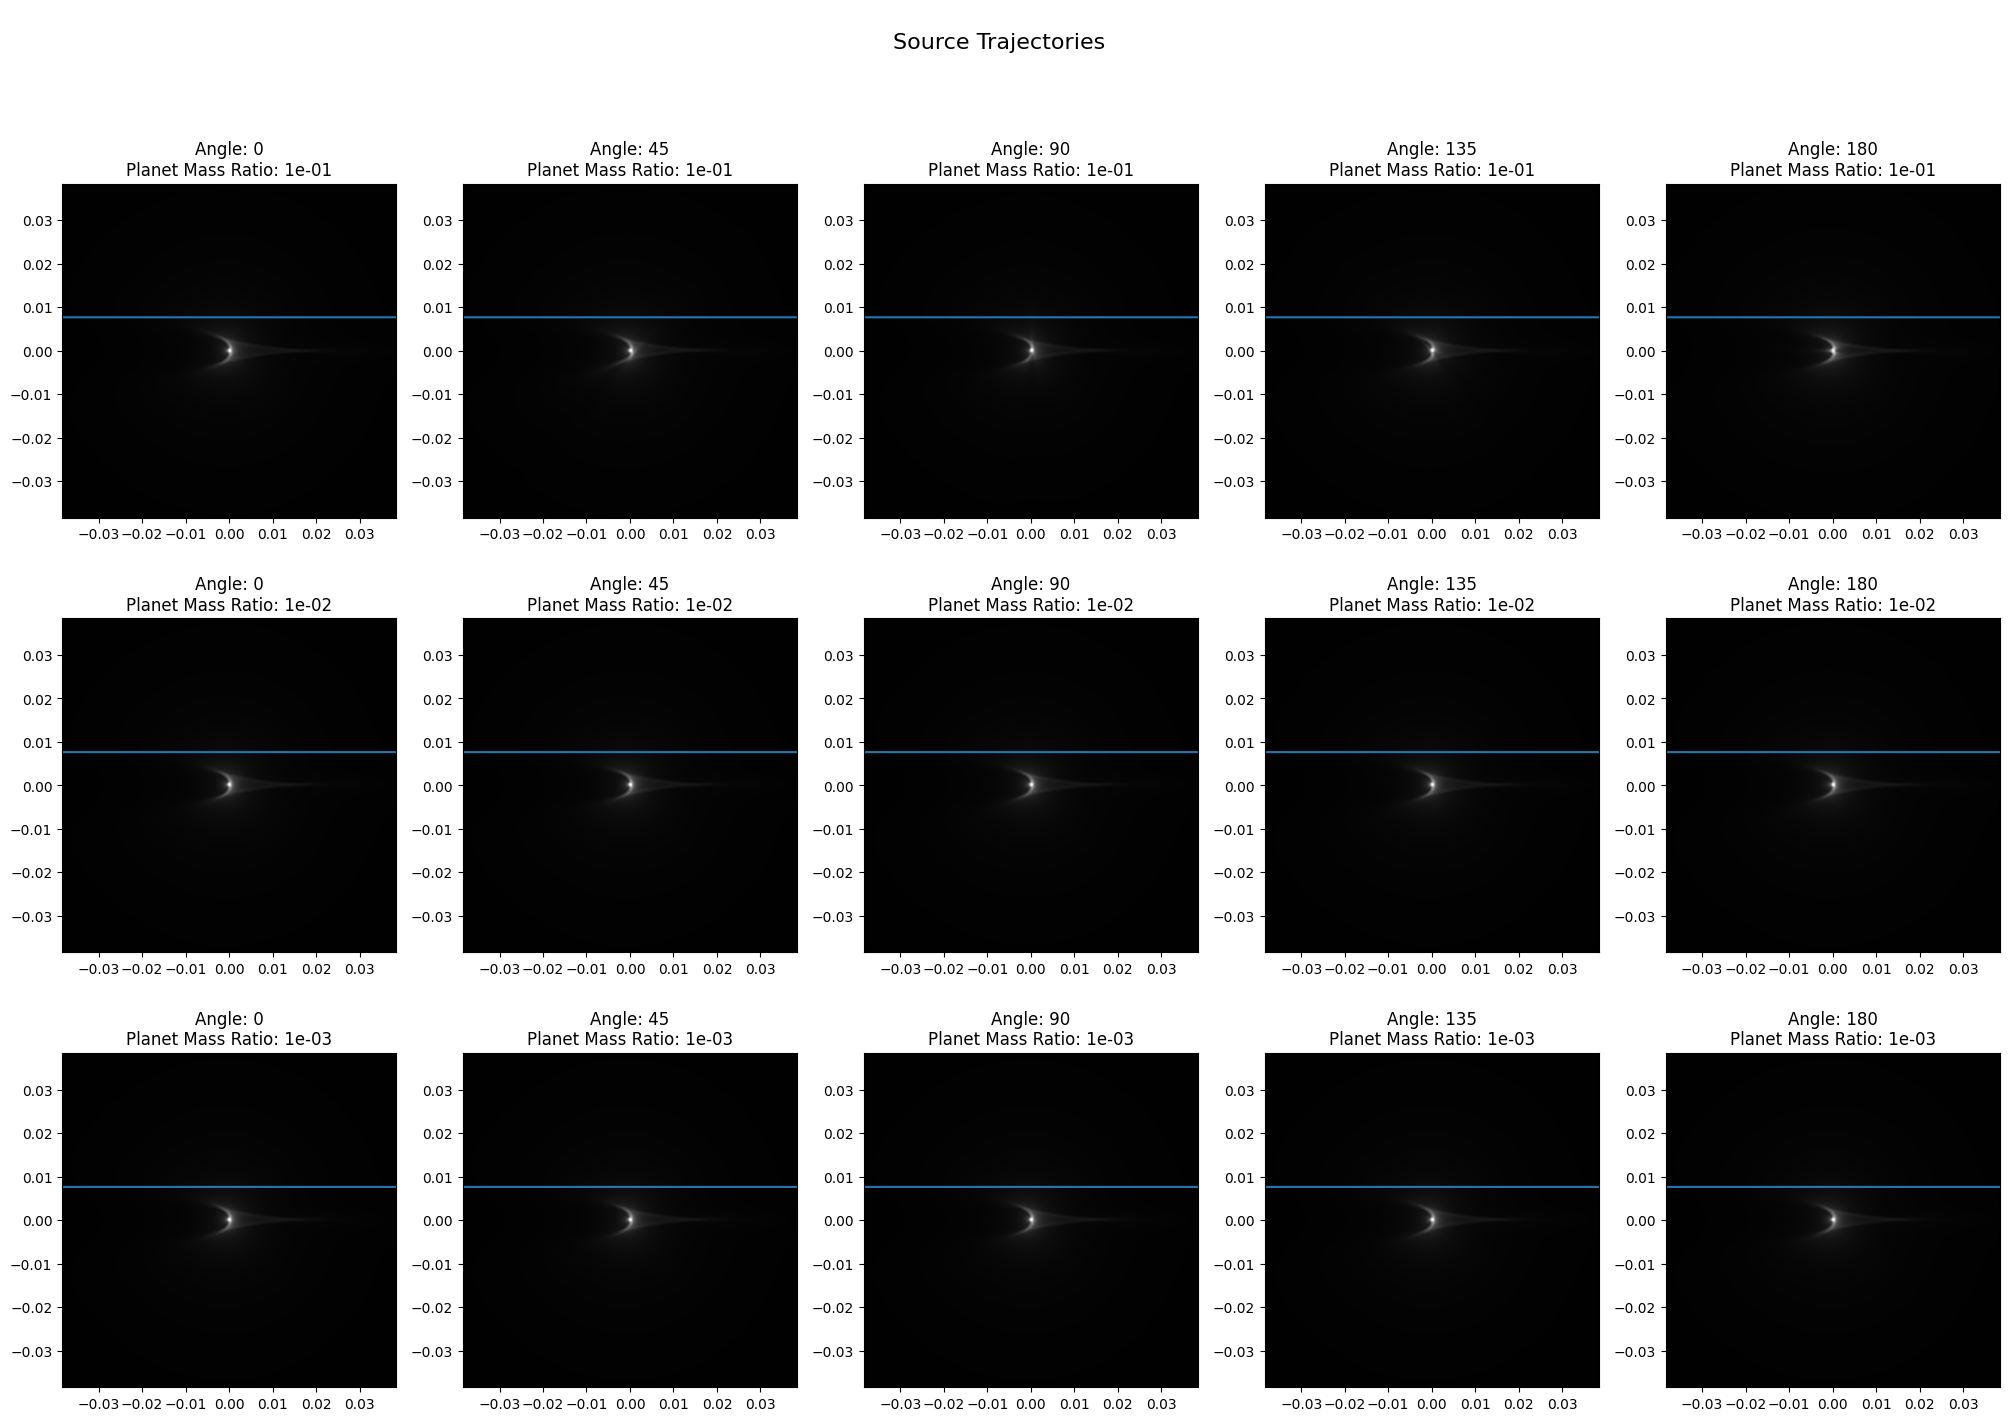

In [232]:
fig = plt.figure(figsize=(25, 16))
all_axes = fig.subplots(3, 5)
axes = all_axes

fig.suptitle('\nSource Trajectories', fontsize=16)

for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {betas[j]}\nPlanet Mass Ratio: {(pmrs[i]):.0e}')

        ax.imshow(convolved_triple_lenses[i, j], cmap='gray', extent=[-ang_width/2, ang_width/2, -ang_width/2, ang_width/2])

        one_configuration_xs = x_distribution[i, j]
        one_configuration_ys = y_distribution[i, j]
        
        if one_curve:
            xs = one_configuration_xs[ind_u, ind_alpha]
            ys = one_configuration_ys[ind_u, ind_alpha]

            ax.plot(xs, ys, label=f'u = {us[ind_u]:.2f}, alpha = {alphas[ind_alpha]:.0f}')

        else:
            for ind_u in range(len(us)):
                for ind_alpha in range(len(alphas)):
                    xs = one_configuration_xs[ind_u, ind_alpha]
                    ys = one_configuration_ys[ind_u, ind_alpha]

                    ax.plot(xs, ys, label=f'u = {us[ind_u]:.2f}, alpha = {alphas[ind_alpha]:.0f}')

        ax.set_xlim(-ang_width/2, ang_width/2)
        ax.set_ylim(-ang_width/2, ang_width/2)

plt.show()

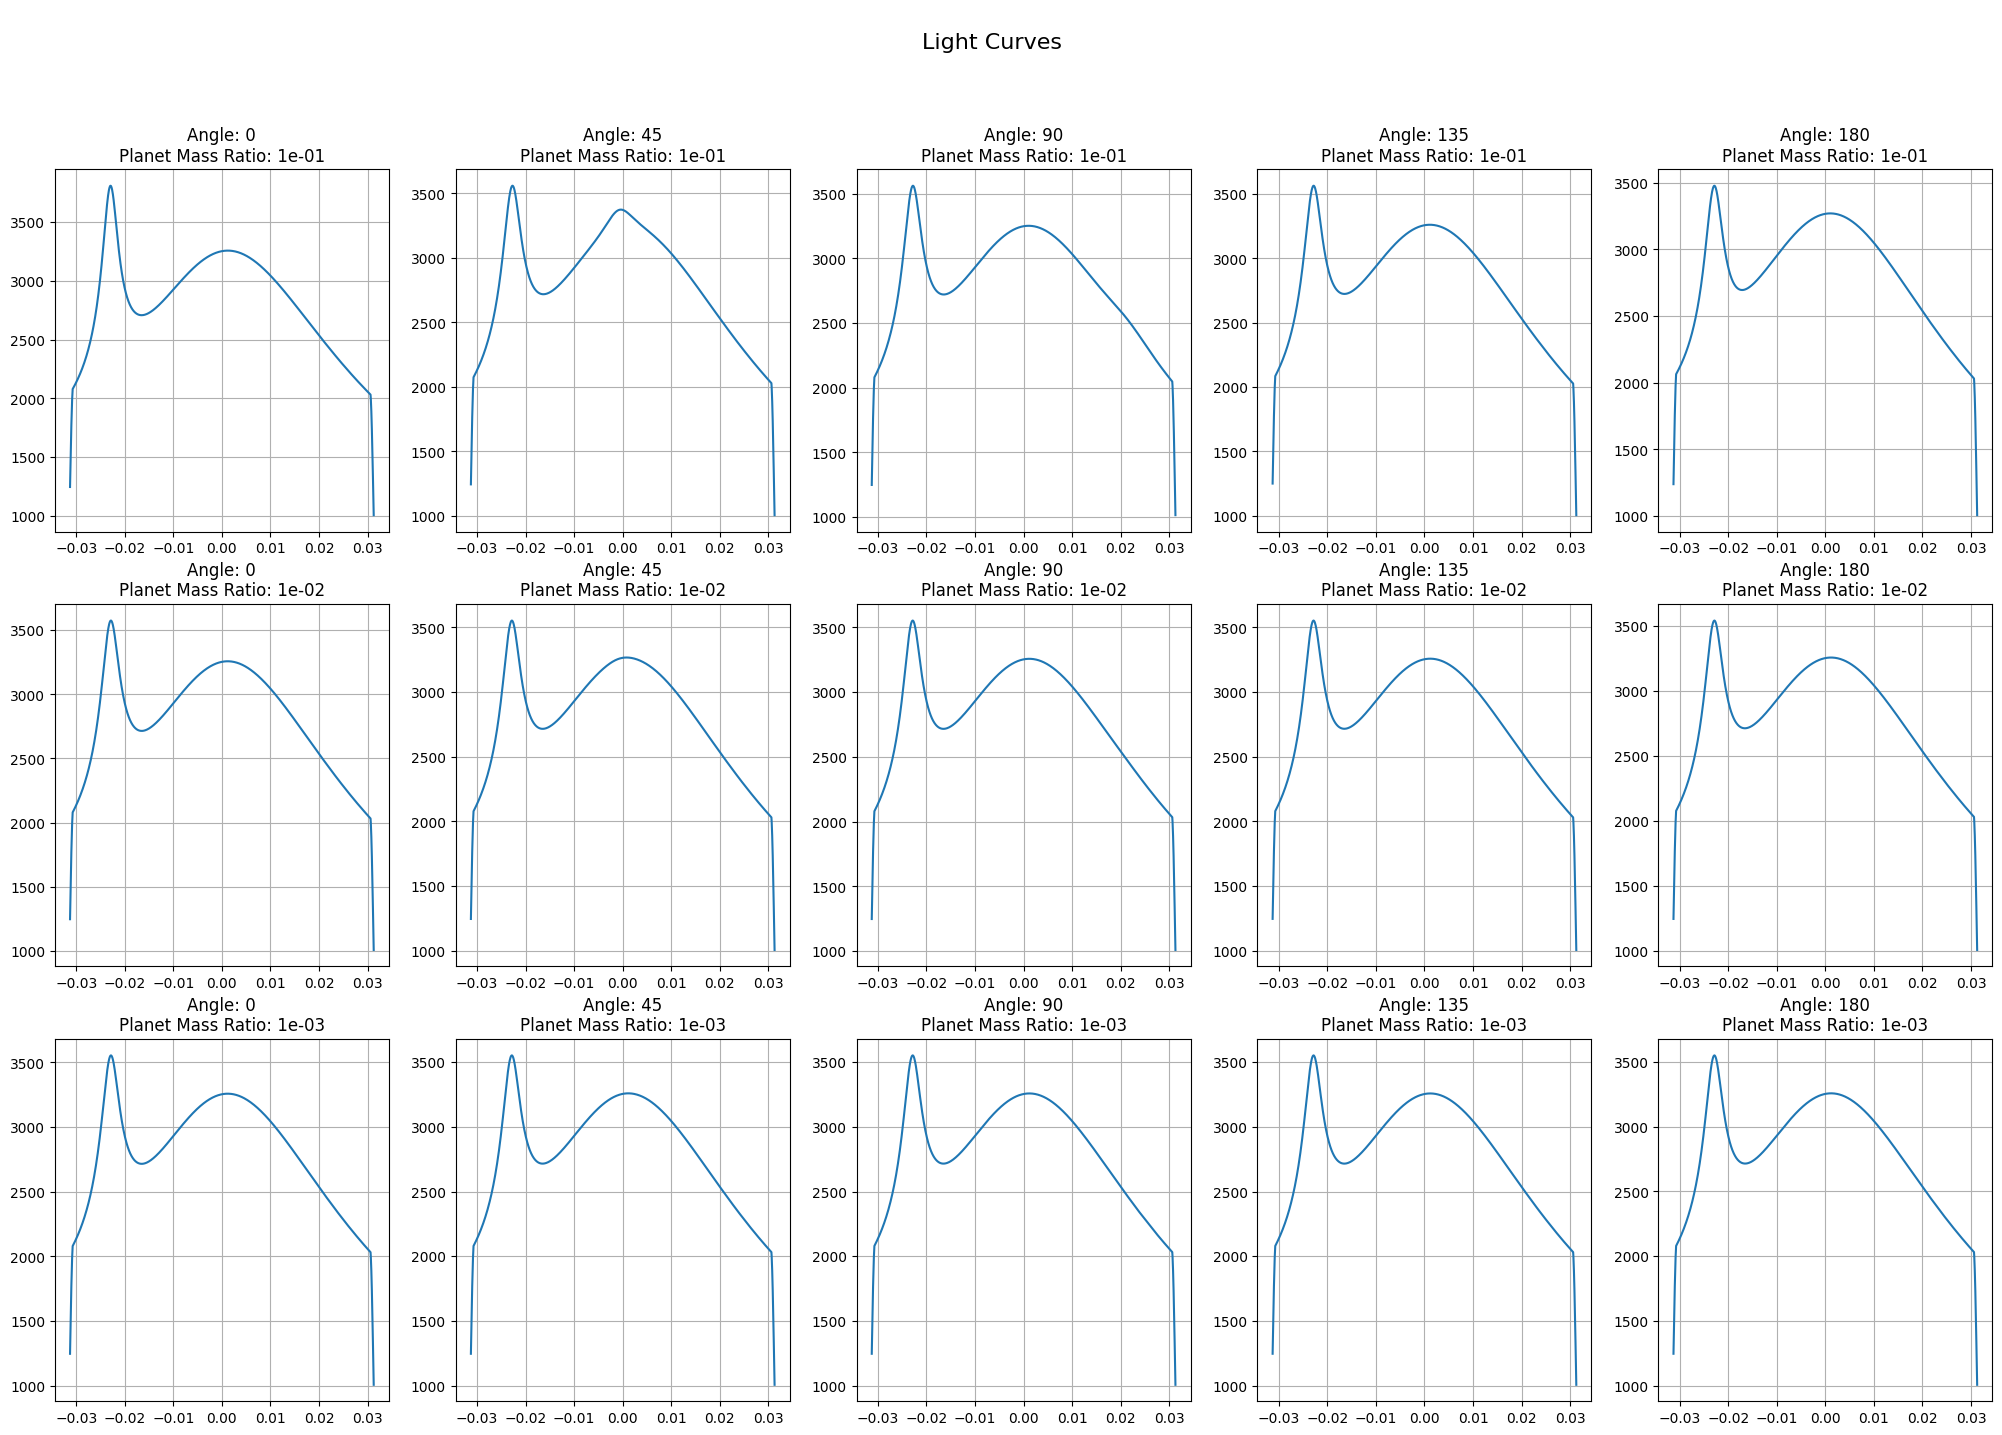

In [233]:
fig = plt.figure(figsize=(25, 16))
all_axes = fig.subplots(3, 5)
axes = all_axes

fig.suptitle('\nLight Curves', fontsize=16)

one_curve = True
ind_u = 1
ind_alpha = 3

for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {betas[j]}\nPlanet Mass Ratio: {(pmrs[i]):.0e}')

        one_configuration_brightness = brightness_distribution[i, j]
        one_configuration_times = time_distribution[i, j]

        if one_curve:
            brightness = one_configuration_brightness[ind_u, ind_alpha]
            times = one_configuration_times[ind_u, ind_alpha]

            ax.plot(times, brightness, label=f'u = {us[ind_u]:.2f}, alpha = {alphas[ind_alpha]:.0f}')

        if not one_curve:
            for ind_u in range(len(us)):
                for ind_alpha in range(len(alphas)):
                    brightness = one_configuration_brightness[ind_u, ind_alpha]
                    times = one_configuration_times[ind_u, ind_alpha]

                    ax.plot(times, brightness, label=f'u = {us[ind_u]:.2f}, alpha = {alphas[ind_alpha]:.0f}')

        # for k, (brightness, times) in enumerate(zip(one_configuration_brightness, one_configuration_times)):
            
        #     # ax.plot(times, brightness, label=f'u = {us[k]:.2f}')

        # ax.set_xlabel('Time')
        # ax.set_ylabel('Brightness')
        ax.grid(True)
        # ax.legend()